# Analysis: performance, pathway importance, gene importance

Six models, one configuration: `mode=sum`, `gene_pooling=attention`, `pathway_pooling=mean`,
`embed_dim=64`, seeds 0/1/2 on TCGA and on GTEx. Everything is computed on the fixed **test set**

Heavy cells write their result under `results/analysis/` and skip the computation if the file
is already there, so the notebook can be re-run freely.

In [1]:
import json, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import kghtt_model_v5 as M
import kghtt_analysis as A

RESULTS = "results"
OUT = os.path.join(RESULTS, "analysis")
os.makedirs(OUT, exist_ok=True)
TAG = "d64"
RUNS = {f"{ds}_s{s}": os.path.join(RESULTS, f"{ds}_sum_gene-attn_s{s}_{TAG}")
        for ds in ("tcga", "gtex") for s in (0, 1, 2)}
DATASETS = ("tcga", "gtex")
pd.set_option("display.width", 200)
print("\n".join(f"{k:10s} {v}  {'OK' if os.path.exists(os.path.join(v, 'run.json')) else 'MISSING'}"
                for k, v in RUNS.items()))

I0000 00:00:1790325337.860417    1120 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790325337.861188    1120 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790325338.602395    1120 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790325341.095441    1120 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

tcga_s0    results/tcga_sum_gene-attn_s0_d64  OK
tcga_s1    results/tcga_sum_gene-attn_s1_d64  OK
tcga_s2    results/tcga_sum_gene-attn_s2_d64  OK
gtex_s0    results/gtex_sum_gene-attn_s0_d64  OK
gtex_s1    results/gtex_sum_gene-attn_s1_d64  OK
gtex_s2    results/gtex_sum_gene-attn_s2_d64  OK


## Load the six models and check them

Each model is rebuilt from the arguments stored in its `run.json`, the weights and the
preprocessors are reloaded, and the test predictions are recomputed. They must match the
predictions saved at training time: this is the guarantee that we are analysing exactly the
models that produced the reported metrics.

In [2]:
runs = {}
for key, path in RUNS.items():
    if not os.path.exists(os.path.join(path, "run.json")):
        print(f"{key:10s} | SKIPPED (not trained yet)")
        continue
    r = A.load_run(path, M)
    ok, err, _ = A.check_reload(r)
    runs[key] = r
    print(f"{key:10s} | test {r['X_cont'].shape} | {len(r['classes'])} classes | "
          f"bal.acc {r['metrics']['balanced_accuracy']:.4f} | reload {'OK' if ok else 'MISMATCH'} ({err:.1e})")
assert runs, "no run available"
DATASETS = tuple(ds for ds in DATASETS if any(k.startswith(ds) for k in runs))
K = len(runs["tcga_s0"]["model"].pathway_names)
print(f"\n{K} pathways, {len(runs['tcga_s0']['meta']['genes'])} genes")

E0000 00:00:1790325469.849787    1120 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


tcga_s0    | test (2161, 5291) | 24 classes | bal.acc 0.9475 | reload OK (0.0e+00)
tcga_s1    | test (2161, 5291) | 24 classes | bal.acc 0.9386 | reload OK (0.0e+00)
tcga_s2    | test (2161, 5291) | 24 classes | bal.acc 0.9468 | reload OK (0.0e+00)
gtex_s0    | test (1714, 5291) | 28 classes | bal.acc 0.9332 | reload OK (0.0e+00)
gtex_s1    | test (1714, 5291) | 28 classes | bal.acc 0.9151 | reload OK (0.0e+00)
gtex_s2    | test (1714, 5291) | 28 classes | bal.acc 0.9285 | reload OK (0.0e+00)

218 pathways, 5291 genes


## Performance: model vs baselines

Balanced accuracy mean and standard deviation over the three seeds, against the baselines trained on the same
split. AUC, log-loss and F1 are also reported.

In [3]:
rows = []
for key, r in runs.items():
    m = r["metrics"]
    rows.append(dict(dataset=r["args"]["dataset"], model="KG-HTT", seed=r["args"]["seed"],
                     bal_acc=m["balanced_accuracy"], macro_f1=m["macro_f1"],
                     log_loss=m["log_loss"], auc=m["macro_auc_ovr"]))
for ds in DATASETS:
    for b in ("lr", "rf", "xgb"):
        p = os.path.join(RESULTS, "baselines", ds, b, "run.json")
        if os.path.exists(p):
            m = json.load(open(p))["metrics"]
            rows.append(dict(dataset=ds, model=b.upper(), seed=np.nan, bal_acc=m["balanced_accuracy"],
                             macro_f1=m["macro_f1"], log_loss=m["log_loss"], auc=m["macro_auc_ovr"]))
perf = pd.DataFrame(rows)
summary = (perf.groupby(["dataset", "model"])
           .agg(n=("bal_acc", "size"), bal_acc_mean=("bal_acc", "mean"), bal_acc_sd=("bal_acc", "std"),
                macro_f1_mean=("macro_f1", "mean"), log_loss_mean=("log_loss", "mean"),
                auc_mean=("auc", "mean")).round(4))
summary.to_csv(f"{OUT}/A1_performance.csv")
summary

n  bal_acc_mean  bal_acc_sd  macro_f1_mean  log_loss_mean  auc_mean
dataset model                                                                      
gtex    KG-HTT  3        0.9256      0.0094         0.9275         0.2153    0.9965
        LR      1        0.9580         NaN         0.9584         0.2054    0.9984
        RF      1        0.9397         NaN         0.9423         0.3055    0.9970
        XGB     1        0.9552         NaN         0.9566         0.1453    0.9973
tcga    KG-HTT  3        0.9443      0.0049         0.9430         0.1965    0.9984
        LR      1        0.9718         NaN         0.9722         0.1079    0.9997
        RF      1        0.9448         NaN         0.9484         0.3979    0.9986
        XGB     1        0.9675         NaN         0.9690         0.1100    0.9993

## Per-class F1 across seeds, against the Logistic Regression

Separates two different problems: classes that oscillate between seeds
and classes that are consistently below the LR baseline in all three seeds.\
`sd` is the spread across the three seeds, `gap_vs_lr` uses the mean over seeds.

In [4]:
def per_class_table(ds):
    f1 = pd.DataFrame({f"s{r['args']['seed']}": r["metrics"]["per_class_f1"]
                       for k, r in runs.items() if r["args"]["dataset"] == ds})
    f1["mean"], f1["sd"] = f1.mean(axis=1), f1.std(axis=1)
    p = os.path.join(RESULTS, "baselines", ds, "lr", "run.json")
    if os.path.exists(p):
        f1["lr"] = pd.Series(json.load(open(p))["metrics"]["per_class_f1"])
        f1["gap_vs_lr"] = f1["mean"] - f1["lr"]
    return f1.round(3).sort_values("mean")

for ds in DATASETS:
    t = per_class_table(ds)
    t.to_csv(f"{OUT}/A2_per_class_f1_{ds}.csv")
    print(f"\n===== {ds.upper()} — per-class F1 (sorted, worst first) =====")
    print(t.to_string())
    print(f"most unstable across seeds: {', '.join(t['sd'].nlargest(3).index)}")


===== TCGA — per-class F1 (sorted, worst first) =====
                                          s0     s1     s2   mean     sd     lr  gap_vs_lr
Esophageal Carcinoma                   0.824  0.892  0.815  0.843  0.042  0.909     -0.066
Glioblastoma Multiforme                0.875  0.851  0.861  0.862  0.012  0.987     -0.125
Cervical & Endocervical Cancer         0.852  0.868  0.877  0.866  0.013  0.922     -0.056
Lung Squamous Cell Carcinoma           0.881  0.890  0.884  0.885  0.004  0.958     -0.073
Uterine Corpus Endometrioid Carcinoma  0.894  0.913  0.887  0.898  0.014  0.923     -0.025
Head & Neck Squamous Cell Carcinoma    0.942  0.885  0.923  0.917  0.029  0.954     -0.038
Pancreatic Adenocarcinoma              0.954  0.920  0.911  0.928  0.022  0.967     -0.039
Kidney Papillary Cell Carcinoma        0.931  0.906  0.952  0.930  0.023  0.945     -0.016
Bladder Urothelial Carcinoma           0.935  0.917  0.945  0.932  0.014  0.965     -0.033
Stomach Adenocarcinoma             

## Confusion Matrices

The three seeds of each dataset side by side with the logistic regression.

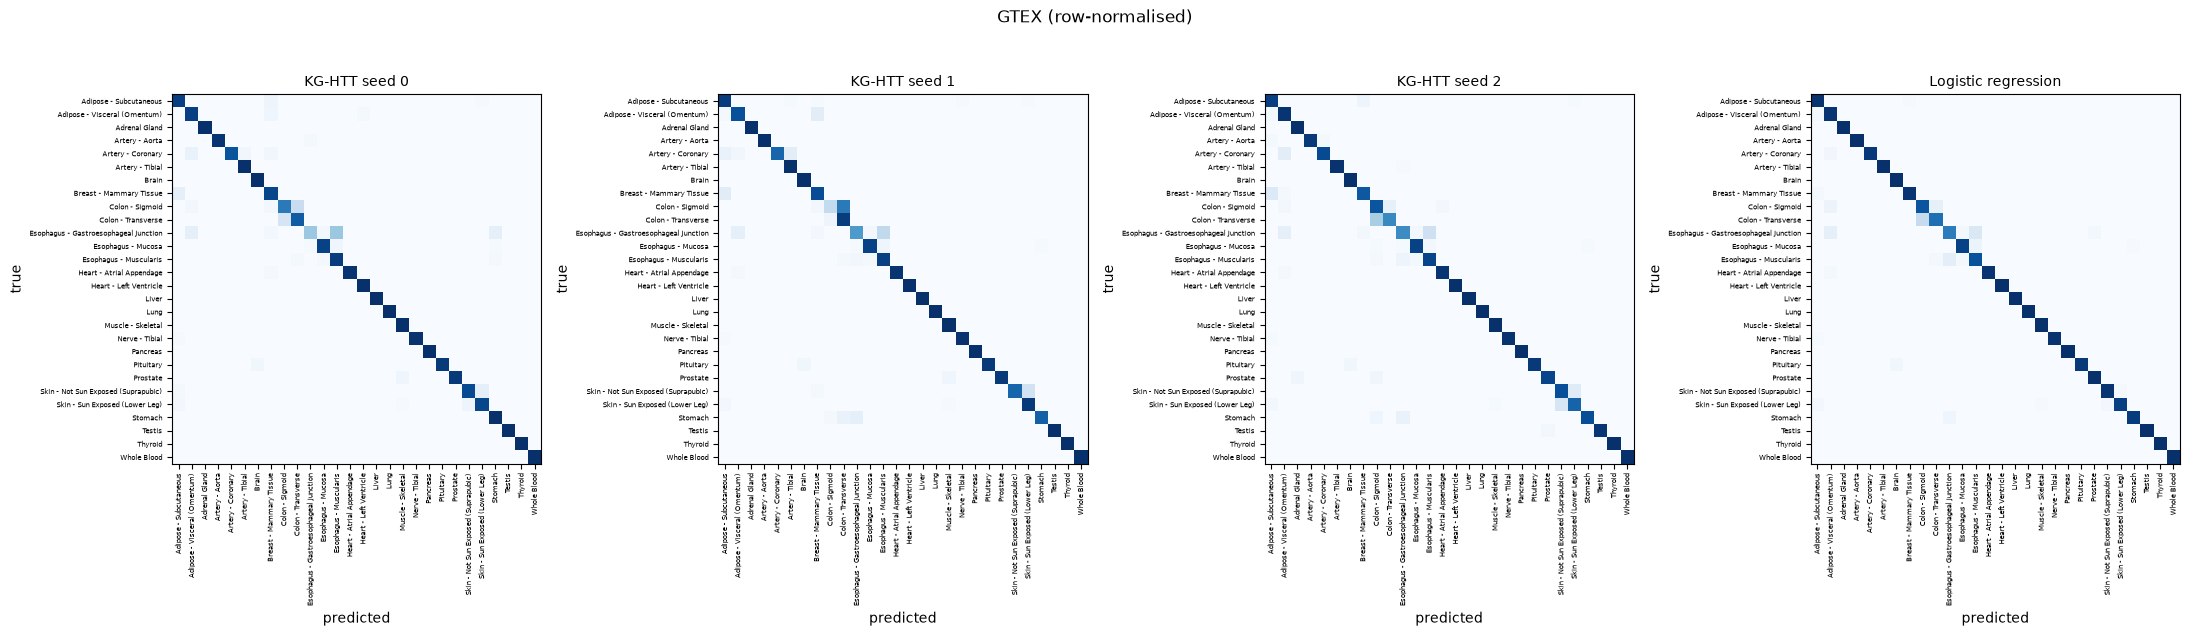

In [6]:
def plot_confusions(ds, normalise=True, figsize=(22, 6)):
    keys = [k for k in runs if runs[k]["args"]["dataset"] == ds]
    classes = runs[keys[0]]["classes"]
    mats, titles = [], []
    for k in keys:
        cm = np.load(os.path.join(runs[k]["run_dir"], "predictions.npz"))["confusion"]
        mats.append(cm); titles.append(f"KG-HTT seed {runs[k]['args']['seed']}")
    p = os.path.join(RESULTS, "baselines", ds, "lr", "predictions.npz")
    if os.path.exists(p):
        mats.append(np.load(p)["confusion"]); titles.append("Logistic regression")
    fig, axes = plt.subplots(1, len(mats), figsize=figsize)
    for ax, cm, ti in zip(np.atleast_1d(axes), mats, titles):
        m = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1) if normalise else cm
        ax.imshow(m, cmap="Blues", vmin=0, vmax=1 if normalise else None)
        ax.set_title(ti, fontsize=10); ax.set_xlabel("predicted"); ax.set_ylabel("true")
        ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=90, fontsize=5); ax.set_yticklabels(classes, fontsize=5)
    plt.suptitle(f"{ds.upper()} (row-normalised)", y=1.02)
    plt.tight_layout(); plt.savefig(f"{OUT}/A3_confusion_{ds}.png", dpi=130, bbox_inches="tight"); plt.show()

plot_confusions("gtex")

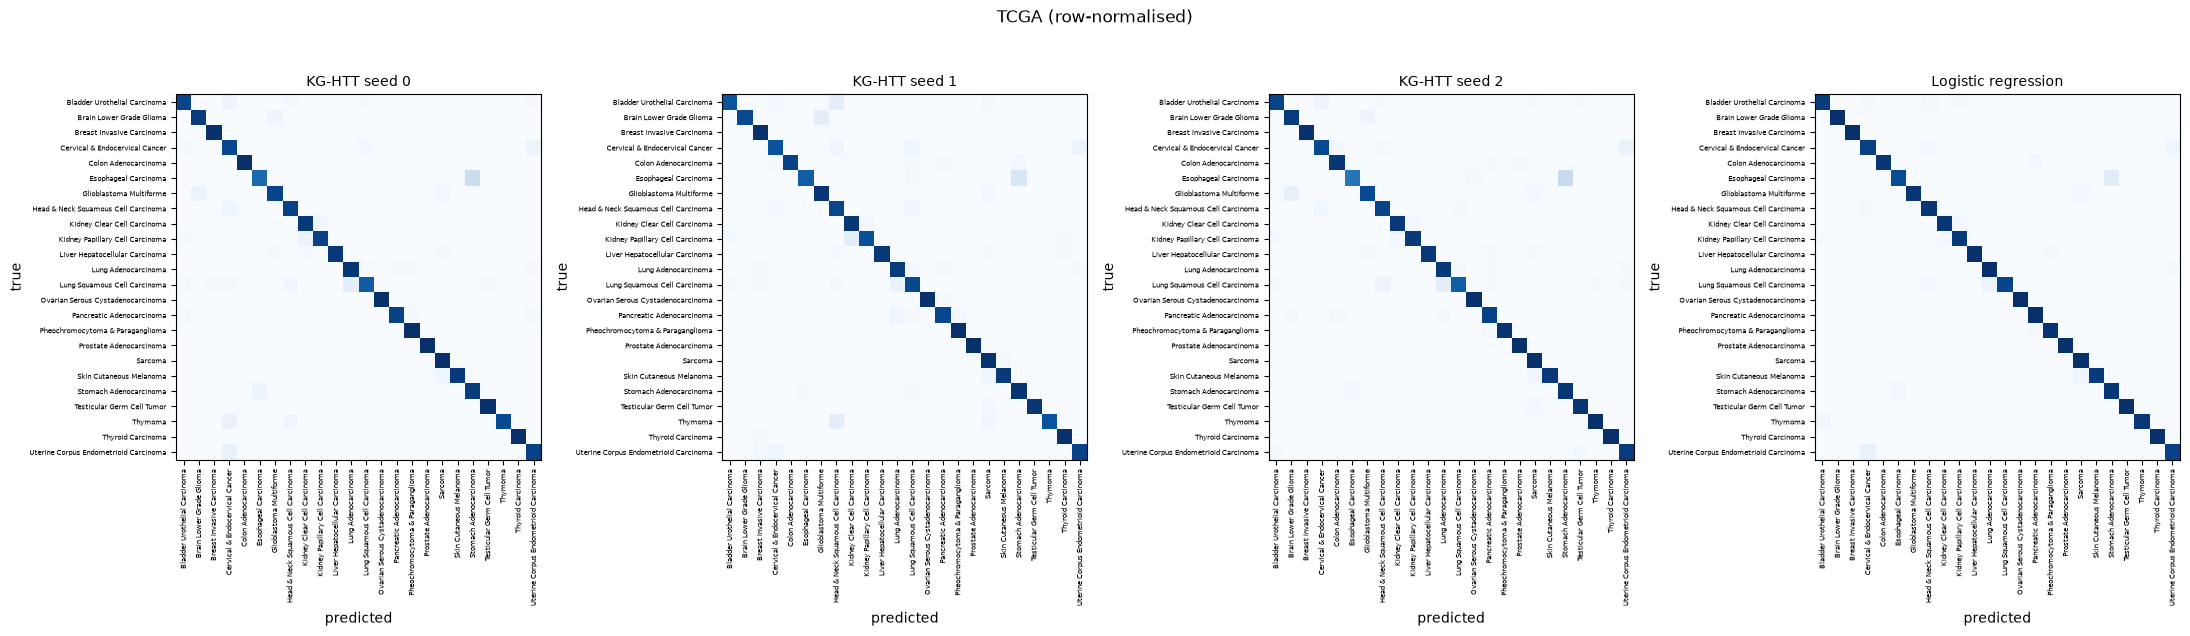

In [7]:
plot_confusions("tcga")

In [ ]:
# where do the errors of each seed actually go?
GROUPS = {"gtex": ["Colon - Sigmoid", "Colon - Transverse", "Esophagus - Gastroesophageal Junction",
                   "Esophagus - Muscularis", "Esophagus - Mucosa", "Stomach"],
          "tcga": ["Esophageal Carcinoma", "Stomach Adenocarcinoma", "Lung Adenocarcinoma",
                   "Lung Squamous Cell Carcinoma", "Glioblastoma Multiforme", "Brain Lower Grade Glioma",
                   "Cervical & Endocervical Cancer", "Uterine Corpus Endometrioid Carcinoma"]}
for ds, group in GROUPS.items():
    classes = runs[f"{ds}_s0"]["classes"]
    sel = [classes.index(c) for c in group if c in classes]
    print(f"\n===== {ds.upper()} — rows = true class, columns = predicted (counts) =====")
    for k in [k for k in runs if runs[k]["args"]["dataset"] == ds]:
        cm = np.load(os.path.join(runs[k]["run_dir"], "predictions.npz"))["confusion"][np.ix_(sel, sel)]
        print(f"\nseed {runs[k]['args']['seed']}")
        print(pd.DataFrame(cm, index=[classes[i][:28] for i in sel],
                           columns=[classes[i][:14] for i in sel]).to_string())


===== GTEX — rows = true class, columns = predicted (counts) =====

seed 0
                              Colon - Sigmoi  Colon - Transv  Esophagus - Ga  Esophagus - Mu  Esophagus - Mu  Stomach
Colon - Sigmoid                           25               8               0               0               0        0
Colon - Transverse                         7              34               0               0               0        0
Esophagus - Gastroesophageal               0               0              13              13               1        3
Esophagus - Muscularis                     0               1               0              58               1        1
Esophagus - Mucosa                         0               0               1               3              63        1
Stomach                                    0               0               0               0               0       43

seed 1
                              Colon - Sigmoi  Colon - Transv  Esophagus - Ga  Esophagus - 

## Timing check before the heavy pass (permutation importance)

Permuting one pathway costs one forward pass of the global blocks + head over the evaluation
samples, repeated `N_PERM` times; the local level and the embedding are computed once and cached.
This cell measures the real cost on three pathways and projects the total, so `N_PERM` and the
number of evaluation samples can be chosen before committing the machine.

`N_EVAL` sub-samples the test set in a stratified way. The full test set is the best option.

In [8]:
from sklearn.model_selection import train_test_split

N_PERM = 10          # permutations per pathway
N_EVAL = 0           # 0 = use the whole test set, otherwise a stratified subsample of this size
BATCH = 64

def eval_indices(r):
    y = r["y"]
    if not N_EVAL or N_EVAL >= len(y):
        return np.arange(len(y))
    idx, _ = train_test_split(np.arange(len(y)), train_size=N_EVAL, stratify=y, random_state=0)
    return np.sort(idx)

import time
probe_key = next(iter(runs))
probe_run = runs[probe_key]
names = probe_run["model"].pathway_names

# warm-up: the first calls pay the TensorFlow graph compilation, which would inflate the estimate
t0 = time.time()
_ = A.pathway_importance(probe_run, n_perm=N_PERM, eval_idx=eval_indices(probe_run),
                         pathways=names[:2], batch_size=BATCH, verbose=False)
warm = time.time() - t0

# two probes of different size: t(n) = cache + n * rate, solved for rate and cache
def probe_time(n_pathways):
    t0 = time.time()
    _ = A.pathway_importance(probe_run, n_perm=N_PERM, eval_idx=eval_indices(probe_run),
                             pathways=names[2:2 + n_pathways], batch_size=BATCH, verbose=False)
    return time.time() - t0

n1, n2 = 4, 12
t1, t2 = probe_time(n1), probe_time(n2)
per_pathway = max((t2 - t1) / (n2 - n1), 1e-9)
cache_cost = max(t1 - n1 * per_pathway, 0.0)
per_model = cache_cost + per_pathway * K
print(f"warm-up (graph compilation): {warm:.0f}s | probes: {t1:.0f}s for {n1}, {t2:.0f}s for {n2} pathways")
print(f"~{per_pathway:.2f}s per pathway, ~{cache_cost:.0f}s one-off cache per model")
print(f"-> {per_model / 60:.1f} min per model, {per_model * len(runs) / 3600:.1f} h for all {len(runs)} models "
      f"(N_PERM={N_PERM}, N_EVAL={'full' if not N_EVAL else N_EVAL})")
print(f"   halving N_PERM or setting N_EVAL~1200 roughly halves it")

warm-up (graph compilation): 86s | probes: 106s for 4, 190s for 12 pathways
~10.59s per pathway, ~63s one-off cache per model
-> 39.5 min per model, 4.0 h for all 6 models (N_PERM=10, N_EVAL=full)
   halving N_PERM or setting N_EVAL~1200 roughly halves it


## Pathway permutation importance

For each pathway, its genes are permuted **jointly** across samples and **only inside that
pathway**: the copies of a shared gene in the other pathways keep their original values. This is
the point of doing the permutation on the pathway vectors rather than on the input columns, and
it is what makes the importance of a shared gene attributable to one pathway at a time.

Because the permutation is joint, it commutes with the per-sample local encoding, so the permuted
pathway vector is simply the cached vector reordered — no re-encoding, and the local level is
computed once per model.

Reported per pathway: `auc_drop` (primary), its standard error over permutations, and
`logloss_rise` (secondary). The per-class AUC drops are stored in the same pass and used in B4.
Run this cell once per night; it skips models already on disk.

In [8]:
def importance_path(key):
    return f"{OUT}/B1_importance_{key}.csv", f"{OUT}/B1_perclass_{key}.npy", f"{OUT}/B1_baseline_{key}.json"

imp, perclass, baselines = {}, {}, {}
for key, r in runs.items():
    fcsv, fnpy, fjson = importance_path(key)
    if os.path.exists(fcsv):
        imp[key] = pd.read_csv(fcsv, index_col=0)
        perclass[key] = np.load(fnpy)
        baselines[key] = json.load(open(fjson))
        print(f"{key}: loaded from disk")
        continue
    print(f"\n=== {key} ===")
    t0 = time.time()
    df, pc, base, _ = A.pathway_importance(r, n_perm=N_PERM, eval_idx=eval_indices(r), batch_size=BATCH)
    df.to_csv(fcsv); np.save(fnpy, pc)
    json.dump({k: (v.tolist() if isinstance(v, np.ndarray) else v)
               for k, v in base.items() if k != "p0"}, open(fjson, "w"))
    imp[key], perclass[key], baselines[key] = df, pc, base
    print(f"{key}: done in {(time.time() - t0) / 60:.0f} min")

tcga_s0: loaded from disk
tcga_s1: loaded from disk
tcga_s2: loaded from disk
gtex_s0: loaded from disk
gtex_s1: loaded from disk
gtex_s2: loaded from disk


### Confidence intervals for the top pathways

The interval comes is computed through a paired percentile bootstrap over the test samples, computed on stored
predictions (no extra forward pass): the same resampled indices are used for the baseline and the
permuted predictions, so the interval is on the paired difference. (Restricted to the top
pathways)

In [10]:
TOP_CI = 30
ci = {}
for key, r in runs.items():
    fci = f"{OUT}/B1b_ci_{key}.csv"
    if os.path.exists(fci):
        ci[key] = pd.read_csv(fci, index_col=0); continue
    top = imp[key]["auc_drop"].nlargest(TOP_CI).index.tolist()
    _, _, base, preds = A.pathway_importance(r, n_perm=5, eval_idx=eval_indices(r), pathways=top,
                                             store_preds_for=top, batch_size=BATCH, verbose=False)
    y = r["y"][base["eval_idx"]]
    rows = {p: A.bootstrap_ci(y, base["p0"], preds[p], n_boot=200) for p in top}
    ci[key] = pd.DataFrame(rows, index=["ci_low", "ci_high"]).T
    ci[key].to_csv(fci)
    print(f"{key}: CI for {TOP_CI} pathways")
ci["tcga_s0"].head()

tcga_s0: CI for 30 pathways
tcga_s1: CI for 30 pathways
tcga_s2: CI for 30 pathways
gtex_s0: CI for 30 pathways
gtex_s1: CI for 30 pathways
gtex_s2: CI for 30 pathways


,ci_low,ci_high
Nitrogen metabolism,-6.445497e-07,0.000061
Taurine and hypotaurine metabolism,8.817849e-06,0.000057
Drug metabolism - other enzymes,9.747259e-06,0.000050
Pantothenate and CoA biosynthesis,4.780615e-06,0.000046
Retinol metabolism,1.337888e-06,0.000043


## Stability of the ranking across seeds

The question this answers is whether the attribution is a property of the data and the
architecture or of the initialisation. Spearman correlation between the importance vectors of
the three seeds of the same dataset, and overlap of their top-20 sets. High stability is what
makes the biological reading of the ranking legitimate; the same numbers are the reference
against which the GTEx vs TCGA difference is judged in B3.

In [11]:
TOP_N = 20
stab = []
for ds in DATASETS:
    keys = [k for k in imp if k.startswith(ds)]
    for a, b in itertools.combinations(keys, 2):
        common = imp[a].index.intersection(imp[b].index)
        rho = spearmanr(imp[a].loc[common, "auc_drop"], imp[b].loc[common, "auc_drop"]).statistic
        rho_ll = spearmanr(imp[a].loc[common, "logloss_rise"], imp[b].loc[common, "logloss_rise"]).statistic
        ov = len(set(imp[a]["auc_drop"].nlargest(TOP_N).index) & set(imp[b]["auc_drop"].nlargest(TOP_N).index))
        stab.append(dict(dataset=ds, pair=f"{a[-2:]} vs {b[-2:]}", spearman_auc=rho,
                         spearman_logloss=rho_ll, top20_overlap=f"{ov}/{TOP_N}"))
stab = pd.DataFrame(stab)
stab.to_csv(f"{OUT}/B2_seed_stability.csv", index=False)
print(stab.round(3).to_string(index=False))

# importance averaged over seeds, with the across-seed spread as uncertainty
mean_imp = {}
for ds in DATASETS:
    keys = [k for k in imp if k.startswith(ds)]
    auc = pd.DataFrame({k: imp[k]["auc_drop"] for k in keys})
    ll = pd.DataFrame({k: imp[k]["logloss_rise"] for k in keys})
    mean_imp[ds] = pd.DataFrame({"auc_drop": auc.mean(axis=1), "auc_drop_sd_seeds": auc.std(axis=1),
                                 "logloss_rise": ll.mean(axis=1),
                                 "n_genes": imp[keys[0]]["n_genes"]}).sort_values("auc_drop", ascending=False)
    mean_imp[ds].to_csv(f"{OUT}/B2_importance_mean_{ds}.csv")
    print(f"\n===== {ds.upper()} — top 20 pathways (mean over seeds) =====")
    print(mean_imp[ds].head(20).round(5).to_string())

dataset     pair  spearman_auc  spearman_logloss top20_overlap
   tcga s0 vs s1         0.166             0.307          4/20
   tcga s0 vs s2         0.288             0.296          5/20
   tcga s1 vs s2         0.104             0.222          3/20
   gtex s0 vs s1         0.155             0.115          2/20
   gtex s0 vs s2         0.136             0.238          7/20
   gtex s1 vs s2         0.057             0.074          6/20

===== TCGA — top 20 pathways (mean over seeds) =====
                                        auc_drop  auc_drop_sd_seeds  logloss_rise  n_genes
pathway                                                                                   
Taurine and hypotaurine metabolism       0.00004            0.00002       0.00299       14
Renin-angiotensin system                 0.00002            0.00002       0.00131       20
Mucin type O-glycan biosynthesis         0.00002            0.00002       0.00062       33
Starch and sucrose metabolism            0.00002  

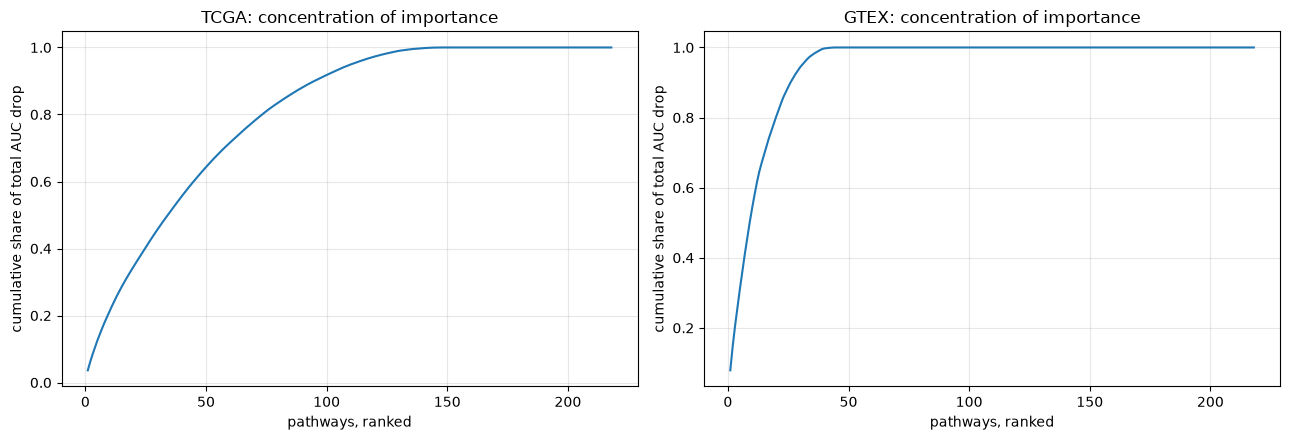

tcga: Spearman(AUC drop, log-loss rise) = 0.603 | 74/218 pathways with drop > 2 SE
gtex: Spearman(AUC drop, log-loss rise) = 0.477 | 13/218 pathways with drop > 2 SE


In [12]:
# how concentrated is the importance? and do AUC and log-loss agree on the ranking?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ds, ax in zip(DATASETS, axes):
    v = mean_imp[ds]["auc_drop"].sort_values(ascending=False).values
    ax.plot(np.arange(1, len(v) + 1), np.cumsum(np.clip(v, 0, None)) / np.clip(v, 0, None).sum())
    ax.set_xlabel("pathways, ranked"); ax.set_ylabel("cumulative share of total AUC drop")
    ax.set_title(f"{ds.upper()}: concentration of importance"); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT}/B2_concentration.png", dpi=130); plt.show()

for ds in DATASETS:
    r = spearmanr(mean_imp[ds]["auc_drop"], mean_imp[ds]["logloss_rise"]).statistic
    se = imp[f"{ds}_s0"]["auc_drop_se"].reindex(mean_imp[ds].index)
    pos = (mean_imp[ds]["auc_drop"] > 2 * se).sum()
    print(f"{ds}: Spearman(AUC drop, log-loss rise) = {r:.3f} | "
          f"{pos}/{len(mean_imp[ds])} pathways with drop > 2 SE")

## B3. GTEx vs TCGA

Same pathways, same genes, same preprocessing, same hyperparameters: the two models differ only
in the task. The comparison is on **ranks**, because the two importances come from different
tasks and their absolute scales are not comparable.

Three readings: (i) the rank correlation between datasets, to be read against the across-seed
correlation of B2 — if seeds agree much more than datasets do, the difference between the two
tasks is real; (ii) the sets — pathways important in both, only in GTEx (tissue identity) or only
in TCGA (tumour biology); (iii) the aggregation by KEGG BRITE category.

Spearman TCGA vs GTEx: 0.054
within-dataset (seeds): TCGA 0.186, GTEx 0.116
-> the gap between these numbers is what makes the task difference interpretable



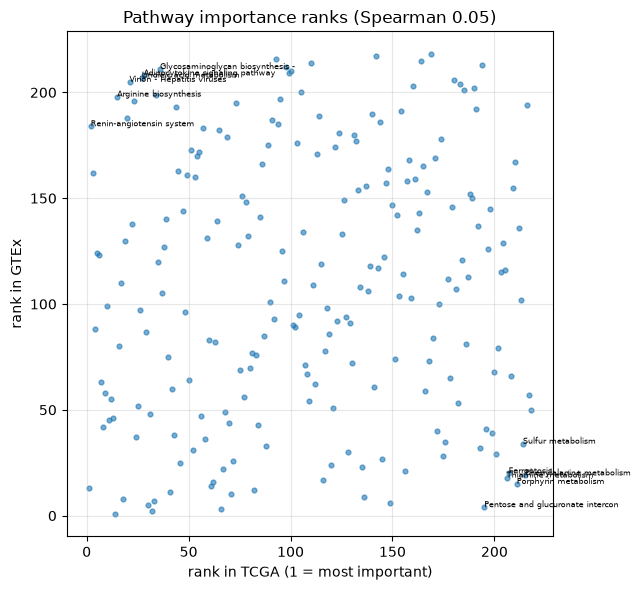

=== most TCGA-specific (high in TCGA, low in GTEx) ===
                                           tcga     gtex  rank_tcga  rank_gtex
pathway                                                                       
Renin-angiotensin system                0.00002 -0.00002        2.0      184.0
Mucin type O-glycan biosynthesis        0.00002 -0.00002        3.0      162.0
ABC transporters                        0.00002 -0.00001        5.0      124.0
Cardiac muscle contraction              0.00002 -0.00001        6.0      123.0
Folate transport and metabolism         0.00002 -0.00001       10.0       99.0
Starch and sucrose metabolism           0.00002 -0.00001        4.0       88.0
N-Glycan biosynthesis                   0.00002 -0.00000        7.0       63.0
Various types of N-glycan biosynthesis  0.00002 -0.00000        9.0       58.0
Cholesterol metabolism                  0.00001 -0.00000       12.0       55.0
Ribosome biogenesis in eukaryotes       0.00002  0.00000        8.0       42

In [13]:
common = mean_imp["tcga"].index.intersection(mean_imp["gtex"].index)
cmp = pd.DataFrame({"tcga": mean_imp["tcga"].loc[common, "auc_drop"],
                    "gtex": mean_imp["gtex"].loc[common, "auc_drop"]})
cmp["rank_tcga"] = cmp["tcga"].rank(ascending=False)
cmp["rank_gtex"] = cmp["gtex"].rank(ascending=False)
cmp["rank_diff"] = cmp["rank_gtex"] - cmp["rank_tcga"]
rho = spearmanr(cmp["tcga"], cmp["gtex"]).statistic
within = stab.groupby("dataset")["spearman_auc"].mean()
print(f"Spearman TCGA vs GTEx: {rho:.3f}")
print(f"within-dataset (seeds): TCGA {within['tcga']:.3f}, GTEx {within['gtex']:.3f}")
print("-> the gap between these numbers is what makes the task difference interpretable\n")

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(cmp["rank_tcga"], cmp["rank_gtex"], s=12, alpha=.6)
for p in cmp["rank_diff"].abs().nlargest(12).index:
    ax.annotate(p[:32], (cmp.loc[p, "rank_tcga"], cmp.loc[p, "rank_gtex"]), fontsize=6)
ax.set_xlabel("rank in TCGA (1 = most important)"); ax.set_ylabel("rank in GTEx")
ax.set_title(f"Pathway importance ranks (Spearman {rho:.2f})"); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT}/B3_rank_scatter.png", dpi=130); plt.show()

print("=== most TCGA-specific (high in TCGA, low in GTEx) ===")
print(cmp.nsmallest(12, "rank_diff" if False else "rank_tcga").assign(d=cmp["rank_diff"]).nlargest(12, "d")[["tcga", "gtex", "rank_tcga", "rank_gtex"]].round(5).to_string())
print("\n=== most GTEx-specific ===")
print(cmp.nsmallest(12, "rank_diff")[["tcga", "gtex", "rank_tcga", "rank_gtex"]].round(5).to_string())
cmp.to_csv(f"{OUT}/B3_tcga_vs_gtex.csv")

In [14]:
# aggregation by KEGG BRITE category
pw = pd.read_csv("data/kegg/kegg_pathways.tsv", sep="\t").set_index("name")
cat = pw["category"].reindex(cmp.index)
sub = pw["subcategory"].reindex(cmp.index)
by_cat = (cmp.assign(category=cat.values, subcategory=sub.values)
          .groupby("category")[["tcga", "gtex"]].agg(["mean", "size"]).round(5))
by_cat.to_csv(f"{OUT}/B3_by_category.csv")
print(by_cat.to_string())
print()
print((cmp.assign(subcategory=sub.values).groupby("subcategory")[["tcga", "gtex"]]
       .mean().assign(n=cmp.assign(s=sub.values).groupby("s").size())
       .sort_values("tcga", ascending=False).head(12).round(5).to_string()))

                                         tcga          gtex     
                                         mean size     mean size
category                                                        
Cellular Processes                    0.00000   14 -0.00001   14
Environmental Information Processing  0.00000   23 -0.00001   23
Genetic Information Processing        0.00001   24 -0.00001   24
Metabolism                            0.00000   76 -0.00000   76
Organismal Systems                    0.00000   81 -0.00001   81

                                              tcga     gtex   n
subcategory                                                    
Membrane transport                         0.00002 -0.00001   1
Metabolism of other amino acids            0.00002  0.00000   4
Translation                                0.00001 -0.00001   4
Circulatory system                         0.00001 -0.00001   3
Chromosome                                 0.00001 -0.00001   2
Nucleotide metabolism          

## B4. Per-class deep dive

`perclass[key]` is the (pathways × classes) matrix of one-vs-rest AUC drops computed in B1:
entry (P, c) is how much the AUC of class c falls when pathway P is destroyed, i.e. **how much
that pathway matters for recognising that tissue or tumour**. Averaged over the three seeds, and
reported as point values — the agreement across seeds takes the place of an interval here.

In [15]:
pc_mean = {ds: np.mean([perclass[k] for k in perclass if k.startswith(ds)], axis=0) for ds in DATASETS}
pc_df = {ds: pd.DataFrame(pc_mean[ds], index=imp[f"{ds}_s0"].index, columns=runs[f"{ds}_s0"]["classes"])
         for ds in DATASETS}
for ds in DATASETS:
    pc_df[ds].to_csv(f"{OUT}/B4_perclass_{ds}.csv")

TOP_PER_CLASS = 5
for ds in DATASETS:
    print(f"\n===== {ds.upper()} — pathways that matter most for each class =====")
    for c in pc_df[ds].columns:
        top = pc_df[ds][c].nlargest(TOP_PER_CLASS)
        print(f"{c[:38]:40s} " + " | ".join(f"{p[:26]} {v:.4f}" for p, v in top.items()))


===== TCGA — pathways that matter most for each class =====
Bladder Urothelial Carcinoma             Adipocytokine signaling pa 0.0001 | Linoleic acid metabolism 0.0001 | Fatty acid biosynthesis 0.0001 | Fat digestion and absorpti 0.0001 | Ether lipid metabolism 0.0000
Brain Lower Grade Glioma                 Histidine metabolism 0.0000 | Virion - Hepatitis viruses 0.0000 | Non-homologous end-joining 0.0000 | Ubiquinone and other terpe 0.0000 | Fatty acid biosynthesis 0.0000
Breast Invasive Carcinoma                Thiamine metabolism 0.0000 | Phenylalanine metabolism 0.0000 | Virion - Ebolavirus, Lyssa 0.0000 | Retinol metabolism 0.0000 | Arachidonic acid metabolis 0.0000
Cervical & Endocervical Cancer           Taurine and hypotaurine me 0.0003 | DNA replication 0.0003 | Mismatch repair 0.0002 | Non-homologous end-joining 0.0002 | Ether lipid metabolism 0.0002
Colon Adenocarcinoma                     Thiamine metabolism 0.0000 | Autophagy - other 0.0000 | Glutathione metabolism 0.00

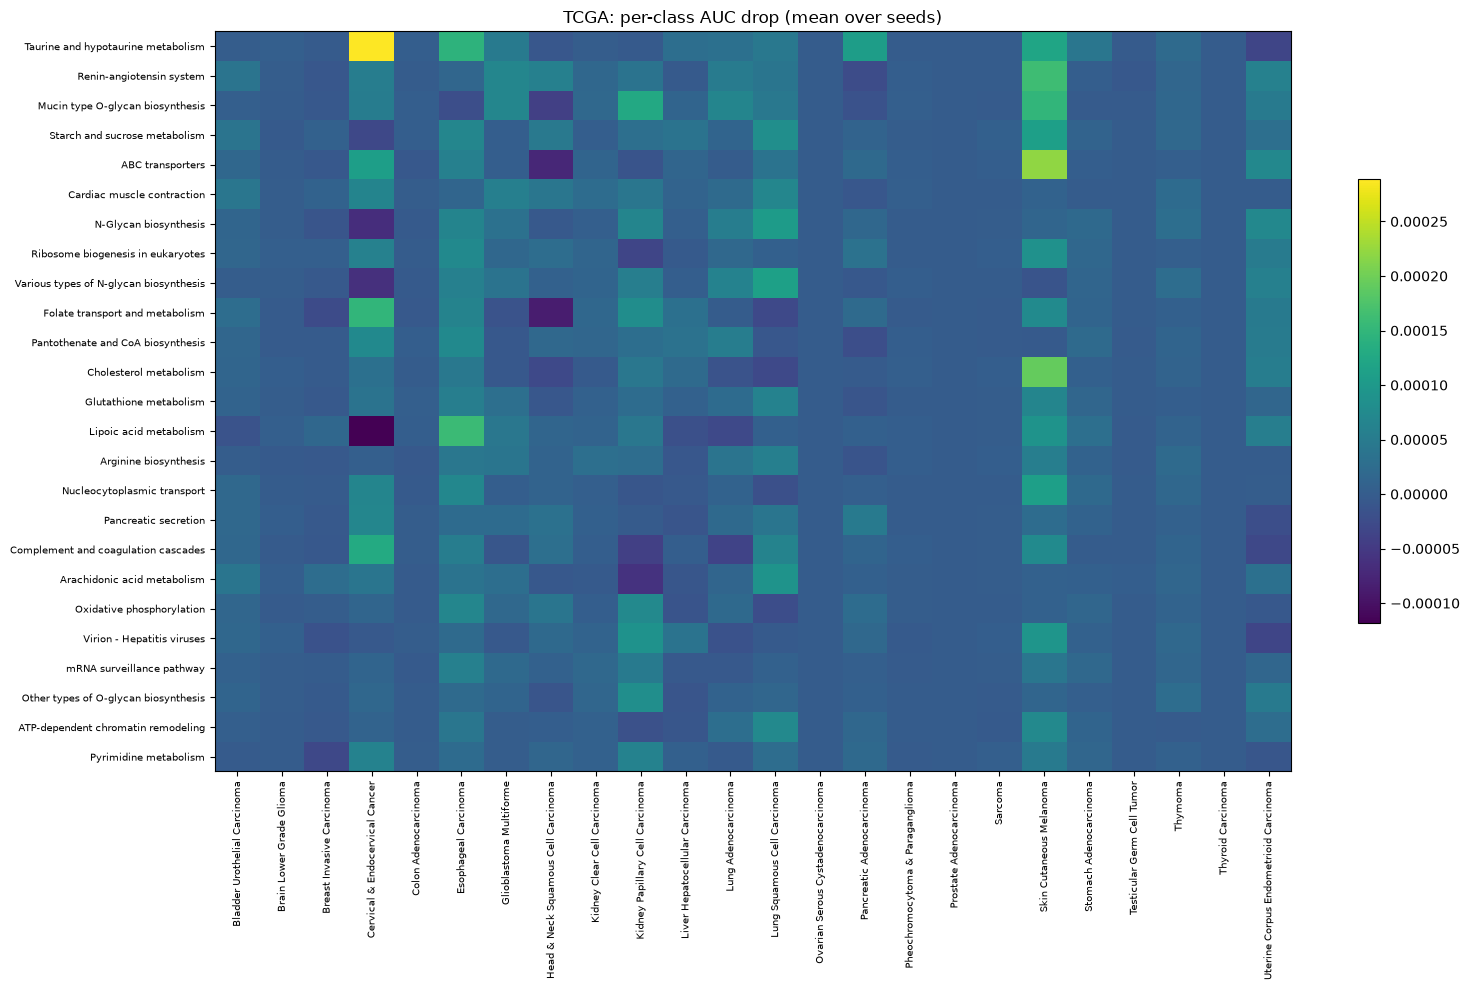

In [16]:
# heat map on the pathways that are most important overall
def heatmap(ds, n_pathways=25):
    top = mean_imp[ds]["auc_drop"].nlargest(n_pathways).index
    m = pc_df[ds].loc[top]
    fig, ax = plt.subplots(figsize=(0.45 * m.shape[1] + 5, 0.32 * n_pathways + 2))
    im = ax.imshow(m.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(m.shape[1])); ax.set_xticklabels(m.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(top))); ax.set_yticklabels([p[:45] for p in top], fontsize=7)
    ax.set_title(f"{ds.upper()}: per-class AUC drop (mean over seeds)")
    plt.colorbar(im, ax=ax, shrink=.6); plt.tight_layout()
    plt.savefig(f"{OUT}/B4_heatmap_{ds}.png", dpi=130); plt.show()

heatmap("tcga")

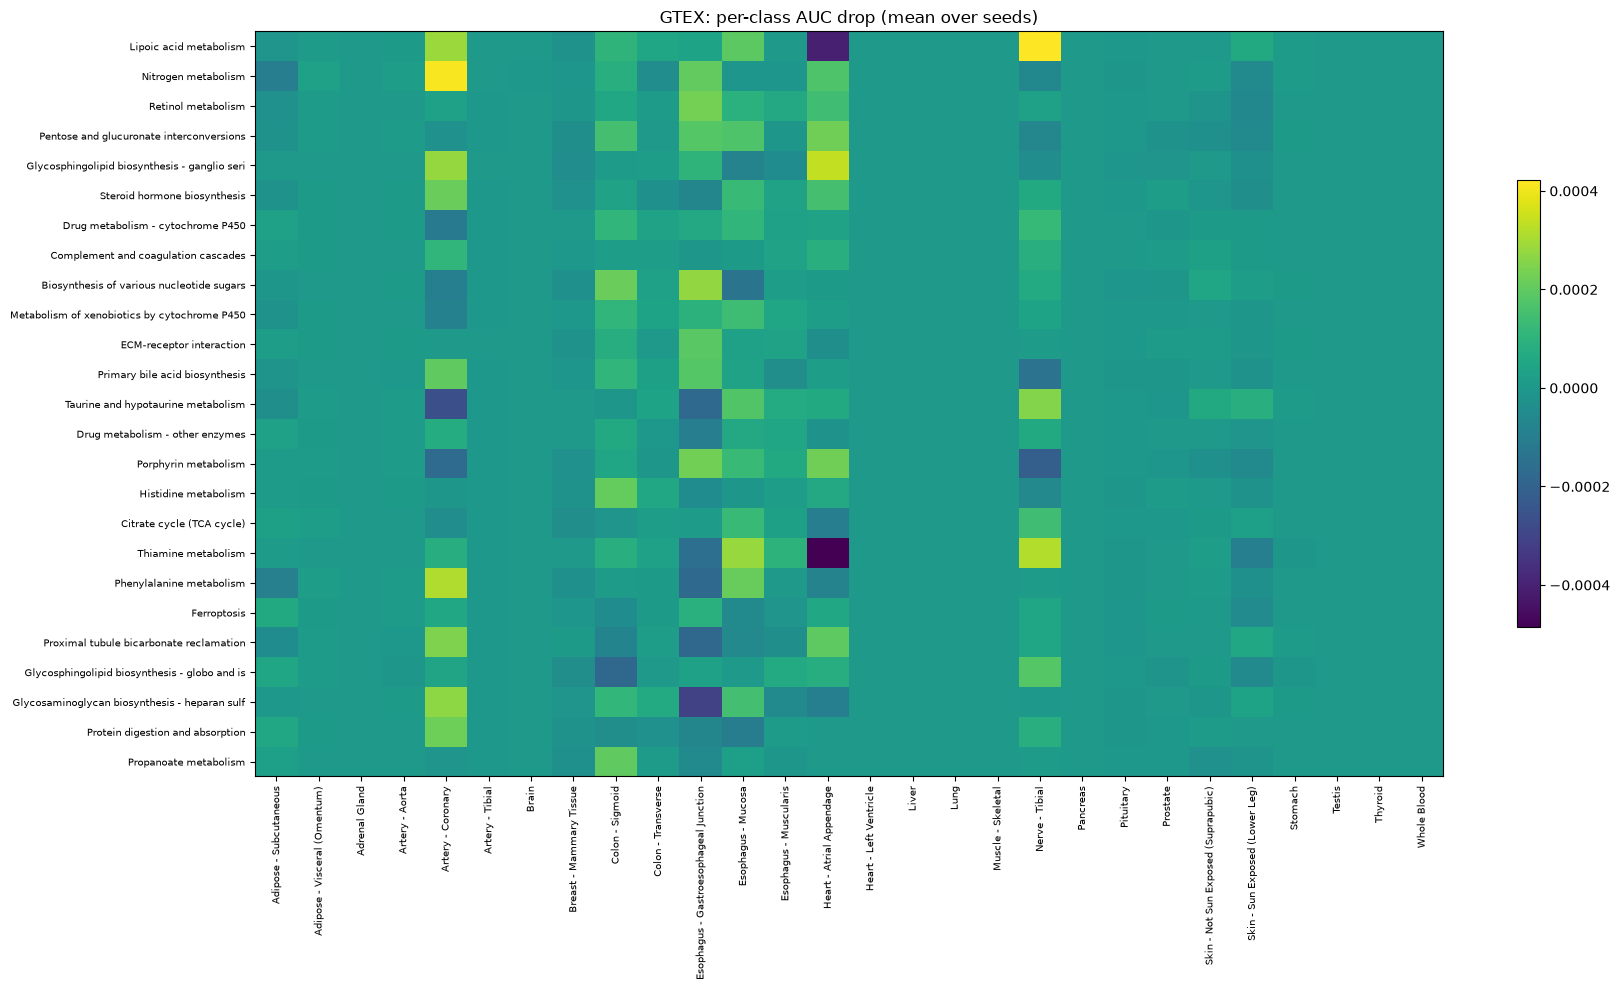

In [17]:
heatmap("gtex")

In [18]:
# matched classes: the same organ, healthy in GTEx and tumour in TCGA
MATCHED = [("Lung", "Lung Adenocarcinoma"), ("Lung", "Lung Squamous Cell Carcinoma"),
           ("Brain", "Glioblastoma Multiforme"), ("Brain", "Brain Lower Grade Glioma"),
           ("Liver", "Liver Hepatocellular Carcinoma"), ("Prostate", "Prostate Adenocarcinoma"),
           ("Thyroid", "Thyroid Carcinoma"), ("Stomach", "Stomach Adenocarcinoma"),
           ("Breast - Mammary Tissue", "Breast Invasive Carcinoma"), ("Testis", "Testicular Germ Cell Tumor")]
rows = []
for g, t in MATCHED:
    if g in pc_df["gtex"].columns and t in pc_df["tcga"].columns:
        a, b = pc_df["gtex"][g], pc_df["tcga"][t]
        rows.append(dict(gtex_class=g, tcga_class=t, spearman=spearmanr(a, b).statistic,
                         top5_gtex=", ".join(a.nlargest(5).index.str[:24]),
                         top5_tcga=", ".join(b.nlargest(5).index.str[:24])))
matched = pd.DataFrame(rows)
matched.to_csv(f"{OUT}/B4_matched_classes.csv", index=False)
print(matched[["gtex_class", "tcga_class", "spearman"]].round(3).to_string(index=False))
print()
for _, r in matched.iterrows():
    print(f"{r['gtex_class'][:22]:24s} GTEx: {r['top5_gtex']}\n{'':24s} TCGA ({r['tcga_class'][:22]}): {r['top5_tcga']}\n")

             gtex_class                     tcga_class  spearman
                   Lung            Lung Adenocarcinoma       NaN
                   Lung   Lung Squamous Cell Carcinoma       NaN
                  Brain        Glioblastoma Multiforme    -0.130
                  Brain       Brain Lower Grade Glioma    -0.056
                  Liver Liver Hepatocellular Carcinoma       NaN
               Prostate        Prostate Adenocarcinoma       NaN
                Thyroid              Thyroid Carcinoma       NaN
                Stomach         Stomach Adenocarcinoma     0.099
Breast - Mammary Tissue      Breast Invasive Carcinoma    -0.049
                 Testis     Testicular Germ Cell Tumor       NaN

Lung                     GTEx: Glycolysis / Gluconeogen, Citrate cycle (TCA cycle, Pentose phosphate pathwa, Pentose and glucuronate , Fructose and mannose met
                         TCGA (Lung Adenocarcinoma): Ubiquinone and other ter, Phototransduction, Sphingolipid metabolism, M

/tmp/ipykernel_109125/2040617589.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rows.append(dict(gtex_class=g, tcga_class=t, spearman=spearmanr(a, b).statistic,


## C1. Gene pooling weights (beta)

`beta` comes out of a forward pass: for each sample and each pathway, the weight given to every
gene when the pathway vector is built. The **normalised entropy** is the sanity check that
matters: 1 means uniform weights, i.e. the attention pooling is behaving like the plain mean it
replaced; values well below 1 mean the model really is selecting genes.

tcga_s0: beta computed
tcga_s1: beta computed
tcga_s2: beta computed
gtex_s0: beta computed
gtex_s1: beta computed
gtex_s2: beta computed
       tcga_s0  tcga_s1  tcga_s2  gtex_s0  gtex_s1  gtex_s2
count    218.0    218.0    218.0    218.0    218.0    218.0
mean       1.0      1.0      1.0      1.0      1.0      1.0
std        0.0      0.0      0.0      0.0      0.0      0.0
min        1.0      1.0      1.0      1.0      1.0      1.0
25%        1.0      1.0      1.0      1.0      1.0      1.0
50%        1.0      1.0      1.0      1.0      1.0      1.0
75%        1.0      1.0      1.0      1.0      1.0      1.0
max        1.0      1.0      1.0      1.0      1.0      1.0


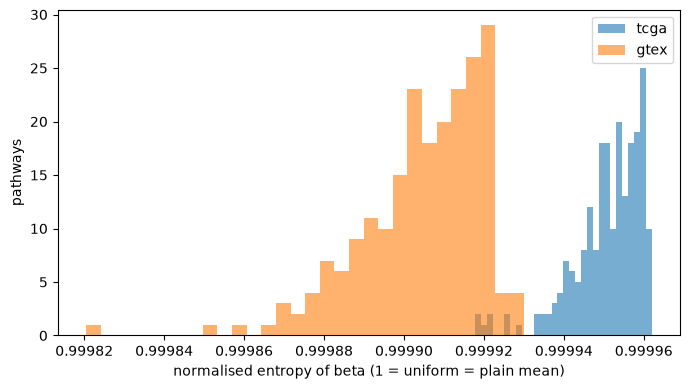

In [19]:
beta, entropy = {}, {}
for key, r in runs.items():
    fe, fb = f"{OUT}/C1_beta_entropy_{key}.csv", f"{OUT}/C1_beta_mean_{key}.npz"
    if os.path.exists(fe) and os.path.exists(fb):
        entropy[key] = pd.read_csv(fe, index_col=0).iloc[:, 0]
        beta[key] = dict(np.load(fb, allow_pickle=True))
        print(f"{key}: loaded from disk")
        continue
    b, e = A.gene_pooling_weights(r, batch_size=BATCH)        # sample-averaged weights only
    e.to_csv(fe); np.savez_compressed(fb, **b)
    beta[key], entropy[key] = b, e
    print(f"{key}: beta computed")
ent = pd.DataFrame(entropy)
print(ent.describe().round(3).to_string())
fig, ax = plt.subplots(figsize=(7, 4))
for ds in DATASETS:
    ax.hist(ent[[k for k in ent.columns if k.startswith(ds)]].mean(axis=1), bins=30, alpha=.6, label=ds)
ax.set_xlabel("normalised entropy of beta (1 = uniform = plain mean)"); ax.set_ylabel("pathways")
ax.legend(); plt.tight_layout(); plt.savefig(f"{OUT}/C1_beta_entropy.png", dpi=130); plt.show()

In [20]:
# genes with the highest mean weight inside the most important pathways
symbol = {g["col"]: (g["symbol"] or g["ensembl"]) for g in runs["tcga_s0"]["meta"]["genes"]}
TOP_PW_FOR_BETA = 10
for ds in DATASETS:
    print(f"\n===== {ds.upper()} — top genes by mean beta =====")
    for p in mean_imp[ds]["auc_drop"].nlargest(TOP_PW_FOR_BETA).index:
        cols = runs[f"{ds}_s0"]["model"].pathway_map[p]
        b = np.mean([beta[k][p] for k in beta if k.startswith(ds)], axis=0)
        top = np.argsort(b)[::-1][:8]
        print(f"{p[:40]:42s} " + ", ".join(f"{symbol.get(cols[i], cols[i])} {b[i]:.3f}" for i in top))


===== TCGA — top genes by mean beta =====
Taurine and hypotaurine metabolism         GGT6 0.072, FMO5 0.072, GAD2 0.071, GAD1 0.071, GGT1 0.071, CDO1 0.071, ADO 0.071, FMO3 0.071
Renin-angiotensin system                   KLK1 0.050, AGT 0.050, MME 0.050, CPA3 0.050, ANPEP 0.050, ACE 0.050, AGTR1 0.050, ENPEP 0.050
Mucin type O-glycan biosynthesis           GALNT3 0.030, GALNT14 0.030, GALNT5 0.030, ST6GALNAC3 0.030, GALNT17 0.030, ST6GALNAC1 0.030, GALNT4 0.030, GALNT10 0.030
Starch and sucrose metabolism              HK2 0.034, GYG2 0.033, PYGB 0.033, ENPP1 0.033, GYS1 0.033, GCK 0.033, PGM2L1 0.033, TREH 0.033
ABC transporters                           ABCC2 0.025, ABCA9 0.025, DEFB1 0.025, ABCB1 0.025, ABCB4 0.025, ABCC5 0.025, ABCB7 0.025, ABCC9 0.025
Cardiac muscle contraction                 FXYD2 0.013, CACNA2D1 0.013, CACNG8 0.013, CACNB4 0.013, SLC8A3 0.013, COX6B1 0.013, SLC9A1 0.013, ATP1A4 0.013
N-Glycan biosynthesis                      MGAT5 0.018, ALG6 0.018, ALG3 0.01

## C2. Gene-level permutation importance inside the top pathways — slow

Here the shortcut does not apply: permuting a single gene mixes samples **within** the pathway,
so the pathway vector has to be re-encoded. Restricted to the top pathways of each dataset and
to seed 0. The copies of the gene in the other pathways are untouched, which is exactly the
shared-gene question: the same gene can be important in one pathway and irrelevant in another.

In [21]:
TOP_PW_GENES = 5
N_PERM_GENE = 5
gene_imp = {}
for ds in DATASETS:
    key = f"{ds}_s0"
    for p in mean_imp[ds]["auc_drop"].nlargest(TOP_PW_GENES).index:
        f = f"{OUT}/C2_genes_{ds}_{p.replace('/', '-').replace(' ', '_')[:40]}.csv"
        if os.path.exists(f):
            gene_imp[(ds, p)] = pd.read_csv(f, index_col=0); continue
        t0 = time.time()
        g = A.gene_importance(runs[key], p, n_perm=N_PERM_GENE, eval_idx=eval_indices(runs[key]),
                              batch_size=BATCH, verbose=False)
        g.to_csv(f); gene_imp[(ds, p)] = g
        print(f"{ds} | {p[:40]:42s} {len(g)} genes in {(time.time() - t0) / 60:.1f} min")
for (ds, p), g in list(gene_imp.items())[:2]:
    print(f"\n{ds} — {p}\n{g.head(10).round(5).to_string()}")

tcga | Taurine and hypotaurine metabolism         14 genes in 3.2 min
tcga | Renin-angiotensin system                   20 genes in 4.5 min
tcga | Mucin type O-glycan biosynthesis           33 genes in 7.5 min
tcga | Starch and sucrose metabolism              30 genes in 6.7 min
tcga | ABC transporters                           40 genes in 9.4 min
gtex | Lipoic acid metabolism                     18 genes in 3.2 min
gtex | Nitrogen metabolism                        14 genes in 2.6 min
gtex | Retinol metabolism                         45 genes in 8.3 min
gtex | Pentose and glucuronate interconversions   24 genes in 4.3 min
gtex | Glycosphingolipid biosynthesis - ganglio   15 genes in 2.7 min

tcga — Taurine and hypotaurine metabolism
        gene_col  auc_drop  auc_drop_se
symbol                                 
FMO2         783   0.00002          0.0
GGT7        2232   0.00001          0.0
FMO3          74   0.00001          0.0
GAD1        2129   0.00000          0.0
CDO1        2159 

## C3. Does beta agree with the permutation?

Rank correlation, inside each pathway, between the mean beta weight and the drop in AUC when the
gene is permuted. Agreement validates beta as a free attribution; disagreement is informative in
itself (a gene can receive a lot of attention and still be redundant with another gene of the
same pathway, so permuting it changes little).

In [22]:
rows = []
for (ds, p), g in gene_imp.items():
    cols = runs[f"{ds}_s0"]["model"].pathway_map[p]
    b = beta[f"{ds}_s0"][p]
    bser = pd.Series({symbol.get(c, c): b[i] for i, c in enumerate(cols)})
    common = g.index.intersection(bser.index)
    if len(common) > 3:
        rows.append(dict(dataset=ds, pathway=p, n_genes=len(common),
                         spearman=spearmanr(g.loc[common, "auc_drop"], bser[common]).statistic))
agree = pd.DataFrame(rows)
agree.to_csv(f"{OUT}/C3_beta_vs_permutation.csv", index=False)
print(agree.round(3).to_string(index=False))
print(f"\nmean Spearman: {agree['spearman'].mean():.3f}")

dataset                                         pathway  n_genes  spearman
   tcga              Taurine and hypotaurine metabolism       14    -0.363
   tcga                        Renin-angiotensin system       20     0.334
   tcga                Mucin type O-glycan biosynthesis       33     0.083
   tcga                   Starch and sucrose metabolism       30    -0.028
   tcga                                ABC transporters       40     0.213
   gtex                          Lipoic acid metabolism       18     0.117
   gtex                             Nitrogen metabolism       14     0.319
   gtex                              Retinol metabolism       45    -0.139
   gtex        Pentose and glucuronate interconversions       24    -0.182
   gtex Glycosphingolipid biosynthesis - ganglio series       15    -0.261

mean Spearman: 0.009


## C4. Shared genes: the same gene in different pathways

The direct answer to the shared-gene question: for genes that belong to more than one of the
analysed pathways, the per-pathway importance of the *same* gene. A gene-level method that
permutes input columns cannot produce this table, because permuting the column destroys the gene
in every pathway at once.

In [23]:
rows = []
for ds in DATASETS:
    per_gene = {}
    for (d, p), g in gene_imp.items():
        if d != ds:
            continue
        for sym, v in g["auc_drop"].items():
            per_gene.setdefault(sym, {})[p] = v
    for sym, d in per_gene.items():
        if len(d) > 1:
            vals = pd.Series(d)
            rows.append(dict(dataset=ds, gene=sym, n_pathways=len(d),
                             max_pathway=vals.idxmax(), max_drop=vals.max(),
                             min_pathway=vals.idxmin(), min_drop=vals.min(),
                             ratio=vals.max() / max(abs(vals.min()), 1e-6)))
COLS = ["dataset", "gene", "n_pathways", "max_pathway", "max_drop", "min_pathway", "min_drop", "ratio"]
shared = pd.DataFrame(rows, columns=COLS)
if len(shared):
    shared = shared.sort_values("max_drop", ascending=False)
    shared.to_csv(f"{OUT}/C4_shared_genes.csv", index=False)
    print(shared.head(20).round(5).to_string(index=False))
    print("\nSame gene, different pathway: the largest contrasts")
    for _, r in shared.nlargest(5, "ratio").iterrows():
        print(f"  {r['gene']:10s} ({r['dataset']}) {r['max_drop']:+.5f} in {r['max_pathway'][:34]:36s} "
              f"vs {r['min_drop']:+.5f} in {r['min_pathway'][:34]}")
else:
    print("no gene belongs to more than one of the analysed pathways — "
          "raise TOP_PW_GENES in C2 so that overlapping pathways are included")

dataset    gene  n_pathways                              max_pathway  max_drop                              min_pathway  min_drop    ratio
   gtex  UGT2A3           2 Pentose and glucuronate interconversions   0.00001                       Retinol metabolism   0.00000  2.18166
   gtex UGT1A10           2 Pentose and glucuronate interconversions   0.00000                       Retinol metabolism   0.00000  3.07347
   gtex  UGT2B7           2                       Retinol metabolism  -0.00000 Pentose and glucuronate interconversions  -0.00000 -0.07142
   gtex  UGT1A1           2                       Retinol metabolism  -0.00000 Pentose and glucuronate interconversions  -0.00000 -0.38711
   gtex UGT2B15           2                       Retinol metabolism  -0.00000 Pentose and glucuronate interconversions  -0.00000 -0.71280
   gtex  UGT1A6           2                       Retinol metabolism  -0.00000 Pentose and glucuronate interconversions  -0.00001 -0.52777
   gtex  UGT1A7           2

## D. Logistic regression with the same permutation procedure — **disabled**

Set `RUN_D = True` to enable. The same pathway permutation applied to the logistic regression,
as an interpretability baseline on equal terms (same metric, same procedure). Note the structural
difference it will expose: in the logistic regression a pathway can only be permuted by permuting
its gene columns, so a shared gene leaks its importance into every pathway that contains it.

In [24]:
RUN_D = False
if RUN_D:
    pass   # to be written together after the rest has been read and discussed